## Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

## Code

In [2]:
traindf = pd.read_csv("train.csv")

features = [
    "time_lag_hours",
    "elapsed_hours_since_txn",
    "txn_amount_gbp",
    "warehouse_amount_gbp",
    "amount_diff_gbp",
    "amount_pct_diff",
    "txn_quantity",
    "warehouse_quantity",
    "quantity_diff",
    "customer_present_in_warehouse_feed",
    "customer_tenure_days",
    "customer_txn_count_90d",
    "customer_historical_discrepancy_rate",
    "warehouse_historical_accuracy",
    "day_of_week",
    "hour_of_day",
    "is_weekend"
]

X_train = traindf[features]
y_train = traindf["decision"]

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("forest", RandomForestClassifier(
        n_estimators=200,
        random_state=16
    ))
])

model.fit(X_train, y_train)

testdf = pd.read_csv("test.csv")

X_test = testdf[features]
y_test = testdf["decision"]

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

# Confidence
probabilities = model.predict_proba(X_test)

print("Classes:", model.classes_)



Accuracy: 0.99875
                          precision    recall  f1-score   support

          auto_reconcile       1.00      1.00      1.00      1716
    await_warehouse_feed       1.00      1.00      1.00       252
         flag_for_review       1.00      1.00      1.00       727
trust_transaction_amount       1.00      1.00      1.00      1002
  trust_warehouse_amount       1.00      0.97      0.99        38
trust_warehouse_quantity       0.99      1.00      1.00       265

                accuracy                           1.00      4000
               macro avg       1.00      0.99      1.00      4000
            weighted avg       1.00      1.00      1.00      4000

Classes: ['auto_reconcile' 'await_warehouse_feed' 'flag_for_review'
 'trust_transaction_amount' 'trust_warehouse_amount'
 'trust_warehouse_quantity']


## Run specific line in `val.csv`

In [3]:
idx = 234

df = pd.read_csv("val.csv")

testidx = model.predict(df.iloc[[idx]][features])
probidx = model.predict_proba(df.iloc[[idx]][features])

print(df.iloc[idx][["transaction_id"]+features])

print("\n" , "Final Decision: ", "\033[1m"+str(testidx[0])+"\033[0m", " with Probability: ", np.reshape(probidx, (len(model.classes_),))[list.index(list(model.classes_), testidx[0])])

print("\n", "REASONING: ")

importance = pd.Series(
    model.named_steps["forest"].feature_importances_,
    index=features
)

print(importance.sort_values(ascending=False))




transaction_id                          TXN103626
time_lag_hours                                5.6
elapsed_hours_since_txn                     61.65
txn_amount_gbp                              20.82
warehouse_amount_gbp                        20.65
amount_diff_gbp                              0.17
amount_pct_diff                            0.0082
txn_quantity                                    1
warehouse_quantity                            1.0
quantity_diff                                 0.0
customer_present_in_warehouse_feed            1.0
customer_tenure_days                          180
customer_txn_count_90d                          2
customer_historical_discrepancy_rate       0.0338
warehouse_historical_accuracy              0.8876
day_of_week                                     1
hour_of_day                                    19
is_weekend                                      0
Name: 234, dtype: object

 Final Decision:  auto_reconcile  with Probability:  0.995

 REASONING: 
a

<BarContainer object of 17 artists>

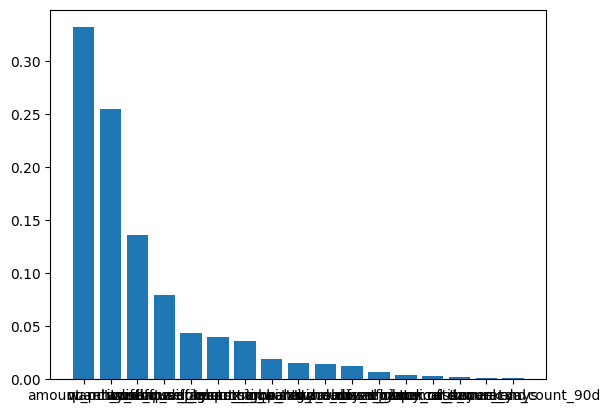

In [4]:
import matplotlib.pyplot as plt 

plt.bar(importance.sort_values(ascending=False).index, importance.sort_values(ascending=False).values)